# 04 · SARIMA Forecasting

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_DIR = "data"
RESULTS_DIR = "results"

df = pd.read_csv(os.path.join(DATA_DIR, "aqi_master_clean.csv"), parse_dates=['Date'])

# Monthly average AQI per city
monthly_df = (
    df.groupby(['City', pd.Grouper(key='Date', freq='MS')])['AQI']
      .mean()
      .reset_index()
)

# Model chosen in notebook 03
best_models = pd.read_csv(os.path.join(RESULTS_DIR, "best_sarima_models.csv"))
best_models

,City,p,d,q,P,D,Q,AIC,Val_MAE_Constrained,Val_MAE_Unconstrained,Enforce
0,Bengaluru,1,0,1,1,0,1,361.75,8.57,9.04,True
1,Delhi,1,1,1,1,1,0,349.70,25.25,24.76,False
2,Kolkata,1,1,1,1,0,1,424.67,25.89,61.31,True
3,Mumbai,0,1,1,1,0,1,404.60,23.34,33.95,True


In [3]:
# MAE, RMSE, MAPE and R2 for one set of predictions
def scores(actual, pred):
    return {
        'MAE': round(mean_absolute_error(actual, pred), 2),
        'RMSE': round(float(np.sqrt(mean_squared_error(actual, pred))), 2),
        'MAPE': round(float(np.mean(np.abs((actual - pred) / actual)) * 100), 2),
        'R2': round(r2_score(actual, pred), 4),
    }

## 1. Forecast and compare with baselines

C:\Users\Raina Samanta\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


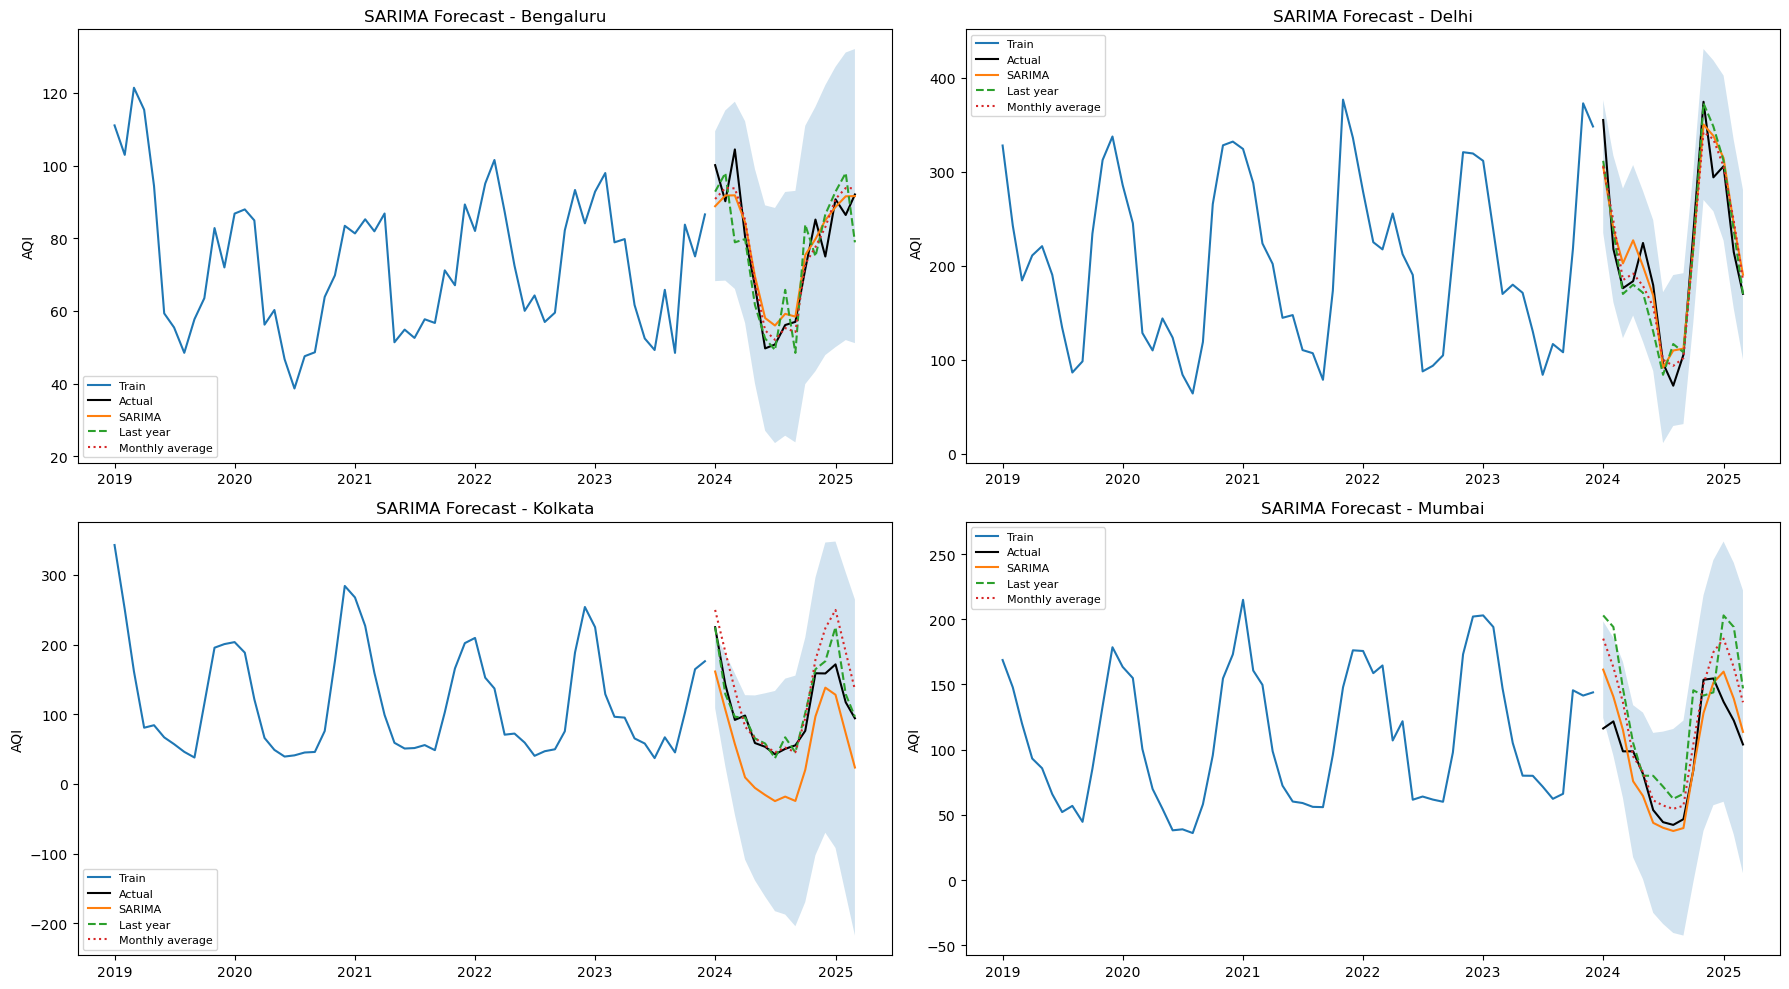

In [5]:
results = []
fitted_models = {}

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for ax, (_, row) in zip(axes.flat, best_models.iterrows()):
    city = row['City']

    series = monthly_df[monthly_df['City'] == city].set_index('Date')['AQI']
    series.index.freq = 'MS'
    train = series[:'2023-12-31']
    test = series['2024-01-01':]

    # SARIMA
    model = SARIMAX(
        train,
        order=(row['p'], row['d'], row['q']),
        seasonal_order=(row['P'], row['D'], row['Q'], 12),
        enforce_stationarity=bool(row['Enforce']),
        enforce_invertibility=bool(row['Enforce'])
    )
    fitted = model.fit(disp=False)
    fitted_models[city] = fitted

    forecast = fitted.get_forecast(steps=len(test))
    sarima_pred = forecast.predicted_mean.values
    conf_int = forecast.conf_int()

    # Baseline 1: repeat the last 12 months of training data (2023)
    last_year_pred = np.tile(train.iloc[-12:].values, 2)[:len(test)]

    # Baseline 2: average of each calendar month over 2019-2023
    month_means = train.groupby(train.index.month).mean()
    monthly_avg_pred = test.index.month.map(month_means).values

    for name, pred in [('SARIMA', sarima_pred),
                       ('Last year', last_year_pred),
                       ('Monthly average', monthly_avg_pred)]:
        results.append({'City': city, 'Model': name, **scores(test.values, pred)})

    # Plot
    ax.plot(train, label='Train')
    ax.plot(test, label='Actual', color='black')
    ax.plot(test.index, sarima_pred, label='SARIMA')
    ax.plot(test.index, last_year_pred, linestyle='--', label='Last year')
    ax.plot(test.index, monthly_avg_pred, linestyle=':', label='Monthly average')
    ax.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], alpha=0.2)
    ax.set_title(f'SARIMA Forecast - {city}')
    ax.set_ylabel('AQI')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [6]:
comparison = pd.DataFrame(results)
comparison.to_csv(os.path.join(RESULTS_DIR, "forecast_comparison.csv"), index=False)
comparison

,City,Model,MAE,RMSE,MAPE,R2
0,Bengaluru,SARIMA,5.14,6.30,6.85,0.8661
1,Bengaluru,Last year,8.65,10.55,10.95,0.6245
2,Bengaluru,Monthly average,4.36,5.50,5.46,0.8978
3,Delhi,SARIMA,24.43,28.04,13.26,0.8949
4,Delhi,Last year,22.38,29.96,12.89,0.8800
5,Delhi,Monthly average,21.87,26.78,10.63,0.9041
6,Kolkata,SARIMA,57.93,60.64,74.78,-0.3320
7,Kolkata,Last year,12.05,17.65,12.89,0.8872
8,Kolkata,Monthly average,29.85,39.17,25.18,0.4444
9,Mumbai,SARIMA,14.98,18.68,15.18,0.7427


**How to read this:** if a baseline scores as well as SARIMA, most of the accuracy comes from the regular yearly pattern rather than the model. With only 15 test months, small differences are not meaningful.

## 2. Residual check (Ljung-Box)

The first 13 residuals are dropped because they are start-up errors from differencing (the big spike at the start), not real forecast errors. `model_df` adjusts the test for the number of fitted parameters.

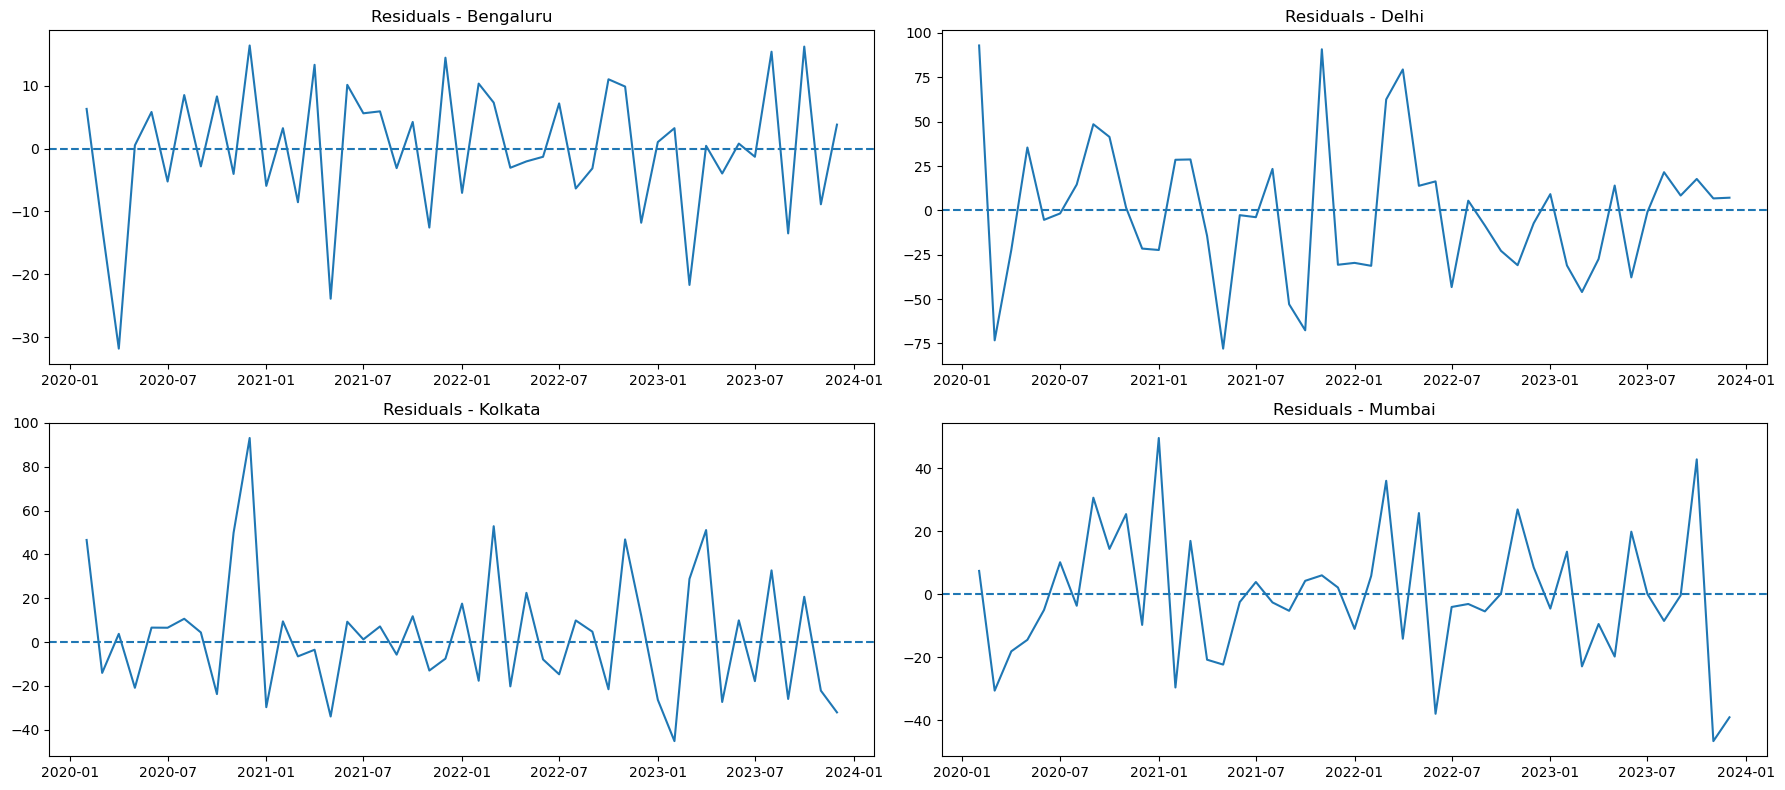

,City,P_Value,Result
0,Bengaluru,0.0031,Autocorrelation remains
1,Delhi,0.0027,Autocorrelation remains
2,Kolkata,0.5006,White noise
3,Mumbai,0.1977,White noise


In [9]:
lb_results = []

fig, axes = plt.subplots(2, 2, figsize=(18, 8))

for ax, (_, row) in zip(axes.flat, best_models.iterrows()):
    city = row['City']
    residuals = fitted_models[city].resid.iloc[13:]
    n_params = row['p'] + row['q'] + row['P'] + row['Q']

    p_value = acorr_ljungbox(residuals, lags=[12], model_df=n_params,
                             return_df=True)['lb_pvalue'].iloc[0]

    lb_results.append({
        'City': city,
        'P_Value': round(p_value, 4),
        'Result': 'White noise' if p_value > 0.05 else 'Autocorrelation remains',
    })

    ax.plot(residuals)
    ax.axhline(0, linestyle='--')
    ax.set_title(f'Residuals - {city}')

plt.tight_layout()
plt.show()

lb_results = pd.DataFrame(lb_results)
lb_results.to_csv(os.path.join(RESULTS_DIR, "ljungbox_results.csv"), index=False)
lb_results

## 3. Mumbai check

Was Mumbai's winter AQI unusually low in 2024? If so, the forecast miss is a sudden drop in level, not a problem with the model's seasonal pattern.

In [11]:
mumbai = monthly_df[monthly_df['City'] == 'Mumbai']
mumbai[mumbai['Date'].dt.month <= 3].groupby(mumbai['Date'].dt.year)['AQI'].mean().round(1)

Date
2019    145.5
2020    139.6
2021    175.1
2022    166.3
2023    181.3
2024    112.2
2025    121.0
Name: AQI, dtype: float64